<a href="https://colab.research.google.com/github/fpellerano/devllm/blob/main/20_5_RAG_Evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Information Retrieval Benchmarking

Notebook 3a showed how to **build** a RAG pipeline. This notebook answers the next question:
*how do you know if it's any good?*

We cover:

1. **Retrieval metrics** — what Precision@k, Recall@k, MAP, and nDCG actually mean
2. **Meet the models** — three embedding models with very different designs
3. **Retriever showdown** — head-to-head benchmark on SciFact, using our own code
4. **RAGAS** — out-of-the-box evaluation of retrieval + generation with Gemini
5. **ELO ranking** — using Gemini-as-judge to tune how many documents to retrieve

In [ ]:
!pip install -qU -r requirements.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 4.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 108.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.6/21.6 MB 84.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 210.1/210.1 kB 23.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.2/126.2 kB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 466.5/466.5 kB 36.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 97.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 29.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 95.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1

In [ ]:
# Only extra dependency for this notebook
!pip install -q datasets

In [ ]:
from google.colab import userdata
import os

os.environ["GOOGLE_API_KEY"] = userdata.get("GOOGLE_API_KEY")

---

## 1. Retrieval Metrics

Your retriever returned $k$ documents for a query. Some are relevant, most aren't.
How do you score that? Four metrics cover the ground.

### Precision@k

*"Of everything you returned, how much was useful?"*

If you retrieve 10 docs and 3 are relevant: Precision@10 = 3/10 = 0.30

$$\text{Precision@k} = \frac{|\text{relevant} \cap \text{top-k}|}{k}$$

In [ ]:
import numpy as np


def precision_at_k(retrieved_ids, relevant_ids, k):
    top_k = retrieved_ids[:k]
    return len(set(top_k) & set(relevant_ids)) / k

### Recall@k

*"Of everything useful that exists, how much did you find?"*

If there are 4 relevant docs total and you found 3: Recall@10 = 3/4 = 0.75

$$\text{Recall@k} = \frac{|\text{relevant} \cap \text{top-k}|}{|\text{relevant}|}$$

In [ ]:
def recall_at_k(retrieved_ids, relevant_ids, k):
    top_k = retrieved_ids[:k]
    return len(set(top_k) & set(relevant_ids)) / max(len(relevant_ids), 1)

### Mean Average Precision (MAP)

*"How consistently do you rank relevant docs high?"*

Average Precision computes Precision at every position where a relevant document appears,
then averages those values. A relevant doc at position 1 contributes more than one at position 10.
MAP is the mean AP across all queries.

$$\text{AP} = \frac{1}{|\text{relevant}|} \sum_{i=1}^{k} \text{Precision@}i \times \text{rel}(i)$$

In [ ]:
def average_precision(retrieved_ids, relevant_ids, k):
    relevant_set = set(relevant_ids)
    hits, total = 0, 0.0
    for i, doc_id in enumerate(retrieved_ids[:k], 1):
        if doc_id in relevant_set:
            hits += 1
            total += hits / i
    return total / max(len(relevant_ids), 1)

### nDCG@k (Normalized Discounted Cumulative Gain)

*"Did you put the good stuff at the top?"*

Like MAP, nDCG cares about *where* in the ranking relevant documents appear.
The discount is logarithmic — position 1 counts far more than position 10.
The score is normalized against the *perfect* ranking (IDCG), so it always falls between 0 and 1.

This is the **primary metric on the [MTEB Leaderboard](https://huggingface.co/spaces/mteb/leaderboard)** —
the standard benchmark people use to compare embedding models.

$$\text{DCG@k} = \sum_{i=1}^{k} \frac{\text{rel}(i)}{\log_2(i+1)} \qquad \text{nDCG@k} = \frac{\text{DCG@k}}{\text{IDCG@k}}$$

In [ ]:
def ndcg_at_k(retrieved_ids, relevant_ids, k):
    relevant_set = set(relevant_ids)
    dcg = sum(
        (1.0 if retrieved_ids[i] in relevant_set else 0.0) / np.log2(i + 2)
        for i in range(min(k, len(retrieved_ids)))
    )
    idcg = sum(1.0 / np.log2(i + 2) for i in range(min(k, len(relevant_ids))))
    return dcg / max(idcg, 1e-10)

### Worked Example

A retriever returns `[D1, D4, D2, D7, D3]`. The ground-truth relevant set is `{D1, D2, D3}`.
Notice that D4 and D7 are irrelevant — and D4 sits at position 2, pushing the relevant D2 down.

In [ ]:
retrieved = ["D1", "D4", "D2", "D7", "D3"]  # what the retriever returned
relevant  = ["D1", "D2", "D3"]                # ground truth

print("Ranking: D1(rel) -> D4 -> D2(rel) -> D7 -> D3(rel)")
print()

for k in [1, 3, 5]:
    print(
        f"k={k}:  "
        f"Precision={precision_at_k(retrieved, relevant, k):.2f}  "
        f"Recall={recall_at_k(retrieved, relevant, k):.2f}  "
        f"MAP={average_precision(retrieved, relevant, k):.2f}  "
        f"nDCG={ndcg_at_k(retrieved, relevant, k):.3f}"
    )

print("\nNotice: nDCG at k=3 is lower than k=5 because the irrelevant D4 at")
print("position 2 pushes D2 down, and the logarithmic penalty is steep at the top.")

Ranking: D1(rel) -> D4 -> D2(rel) -> D7 -> D3(rel)

k=1:  Precision=1.00  Recall=0.33  MAP=0.33  nDCG=1.000
k=3:  Precision=0.67  Recall=0.67  MAP=0.56  nDCG=0.704
k=5:  Precision=0.60  Recall=1.00  MAP=0.76  nDCG=0.885

Notice: nDCG at k=3 is lower than k=5 because the irrelevant D4 at
position 2 pushes D2 down, and the logarithmic penalty is steep at the top.


---

## 2. Meet the Models

We'll benchmark three embedding models that represent different design philosophies.
The key difference is how they handle the **asymmetry** between queries and documents.

### Model 1: `paraphrase-MiniLM-L6-v2` (Symmetric)

A small, fast model. **Symmetric** means queries and documents are encoded
the same way — no prefix, no special treatment. You just pass the text in.

| Property | Value |
|---|---|
| Parameters | 22M |
| Dimensions | 384 |
| Query prefix | *None* |

### Model 2: `mxbai-embed-large-v1` (Asymmetric, query prefix)

A larger model trained to distinguish queries from documents.
The [model card on HuggingFace](https://huggingface.co/mixedbread-ai/mxbai-embed-large-v1)
specifies that queries should be prefixed with:

> `"Represent this sentence for searching relevant passages: "`

Documents are encoded without any prefix. This **asymmetric** encoding helps the model
learn that a short question and a long passage play different roles in retrieval.

| Property | Value |
|---|---|
| Parameters | 335M |
| Dimensions | 1024 |
| Query prefix | `"Represent this sentence for searching relevant passages: "` |
| Document prefix | *None* |

### Model 3: `intfloat/e5-large-v2` (Instruction-tuned)

E5 takes a different approach: **both** queries and documents get a prefix, but
different ones. From the [model card](https://huggingface.co/intfloat/e5-large-v2):

> Queries: `"query: "`    Documents: `"passage: "`

This is called **instruction-tuned** embedding — the prefix tells the model what *role*
the text plays, similar to how you prompt an LLM with a system message.

| Property | Value |
|---|---|
| Parameters | 335M |
| Dimensions | 1024 |
| Query prefix | `"query: "` |
| Document prefix | `"passage: "` |

### Why prefixes matter

These prefixes are **not optional decoration** — the model was trained with them.
Using the wrong prefix (or none at all) can drop nDCG by 10–20 points.
Always check the model card on HuggingFace before using an embedding model.

In [ ]:
import torch
from sentence_transformers import SentenceTransformer

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

model_configs = {
    "MiniLM-L6": {
        "name": "paraphrase-MiniLM-L6-v2",
        "query_prefix": "",
        "doc_prefix": "",
    },
    "mxbai-large": {
        "name": "mixedbread-ai/mxbai-embed-large-v1",
        "query_prefix": "Represent this sentence for searching relevant passages: ",
        "doc_prefix": "",
    },
    "e5-large": {
        "name": "intfloat/e5-large-v2",
        "query_prefix": "query: ",
        "doc_prefix": "passage: ",
    },
}

Using device: cuda


---

## 3. Retriever Showdown on SciFact

[SciFact](https://huggingface.co/datasets/mteb/scifact) is a scientific claim verification
dataset from the BEIR benchmark suite. Each query is a scientific claim, the corpus is
~5,000 paper abstracts, and each query has labeled relevant documents.

This is one of the standard datasets used by the
[MTEB Leaderboard](https://huggingface.co/spaces/mteb/leaderboard) to rank embedding models.
By implementing the evaluation ourselves, we're doing exactly what MTEB does under the hood.

In [ ]:
from datasets import load_dataset
from collections import defaultdict

# Load SciFact
qrels   = load_dataset("mteb/scifact", split="test")
corpus  = load_dataset("mteb/scifact", name="corpus", split="corpus")
queries = load_dataset("mteb/scifact", name="queries", split="queries")

corpus_lookup = {row["_id"]: row["text"] for row in corpus}
query_lookup  = {row["_id"]: row["text"] for row in queries}

# Relevance map: query_id -> set of relevant corpus_ids
relevance = defaultdict(set)
for row in qrels:
    if row["score"] >= 1:
        relevance[row["query-id"]].add(row["corpus-id"])

eval_queries = {qid: query_lookup[qid] for qid in relevance if qid in query_lookup}
corpus_ids   = list(corpus_lookup.keys())
corpus_texts = list(corpus_lookup.values())

print(f"Corpus: {len(corpus_ids)} abstracts")
print(f"Queries with relevance labels: {len(eval_queries)}")
print(f"\nExample claim:\n  {list(eval_queries.values())[0][:150]}...")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

train.jsonl: 0.00B [00:00, ?B/s]

test.jsonl: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/919 [00:00<?, ? examples/s]

...

corpus.jsonl: 0.00B [00:00, ?B/s]

Generating corpus split:   0%|          | 0/5183 [00:00<?, ? examples/s]

queries.jsonl: 0.00B [00:00, ?B/s]

Generating queries split:   0%|          | 0/1109 [00:00<?, ? examples/s]

Corpus: 5183 abstracts
Queries with relevance labels: 300

Example claim:
  0-dimensional biomaterials show inductive properties....


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

# Encode the corpus with each model
# This is the most expensive step — ~30s per model on GPU, a few minutes on CPU
model_data = {}

for label, cfg in model_configs.items():
    print(f"\nLoading and encoding with {label} ({cfg['name']})...")
    st_model = SentenceTransformer(cfg["name"]).to(device)

    # Documents get the doc_prefix (empty for MiniLM and mxbai, "passage: " for e5)
    doc_texts = [cfg["doc_prefix"] + t for t in corpus_texts]
    embeddings = st_model.encode(
        doc_texts, batch_size=64, show_progress_bar=True, convert_to_numpy=True
    )

    model_data[label] = {
        "model": st_model,
        "corpus_embeddings": embeddings,
        "query_prefix": cfg["query_prefix"],
    }
    print(f"  Embedding shape: {embeddings.shape}")


Loading and encoding with MiniLM-L6 (paraphrase-MiniLM-L6-v2)...


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/201 [00:00<?, ?B/s]

Batches:   0%|          | 0/81 [00:00<?, ?it/s]

  Embedding shape: (5183, 1024)


In [ ]:
def retrieve(query_text, model_label, k=10):
    """Retrieve top-k corpus IDs using a given model."""
    data = model_data[model_label]
    q_emb = data["model"].encode(
        [data["query_prefix"] + query_text], convert_to_numpy=True
    )
    sims = cosine_similarity(q_emb, data["corpus_embeddings"])[0]
    top_k_idx = sims.argsort()[::-1][:k]
    return [corpus_ids[i] for i in top_k_idx]


def evaluate_retriever(model_label, k=10):
    """Run all metrics for a model across every query."""
    metrics = {"P@k": [], "R@k": [], "MAP": [], "nDCG@k": []}
    for qid, qtext in eval_queries.items():
        retrieved = retrieve(qtext, model_label, k=k)
        rel = list(relevance[qid])
        metrics["P@k"].append(precision_at_k(retrieved, rel, k))
        metrics["R@k"].append(recall_at_k(retrieved, rel, k))
        metrics["MAP"].append(average_precision(retrieved, rel, k))
        metrics["nDCG@k"].append(ndcg_at_k(retrieved, rel, k))
    return {m: np.mean(v) for m, v in metrics.items()}

In [ ]:
# Run the benchmark
K = 10
results = {}

for label in model_configs:
    results[label] = evaluate_retriever(label, k=K)
    print(f"\n{label} @ k={K}")
    for metric, score in results[label].items():
        print(f"  {metric}: {score:.4f}")


MiniLM-L6 @ k=10
  P@k: 0.0733
  R@k: 0.6532
  MAP: 0.4327
  nDCG@k: 0.4895

mxbai-large @ k=10
  P@k: 0.1000
  R@k: 0.8832
  MAP: 0.6996
  nDCG@k: 0.7462

e5-large @ k=10
  P@k: 0.0957
  R@k: 0.8455
  MAP: 0.6851
  nDCG@k: 0.7281


               P@k    R@k    MAP  nDCG@k
MiniLM-L6   0.0733 0.6532 0.4327  0.4895
mxbai-large 0.1000 0.8832 0.6996  0.7462
e5-large    0.0957 0.8455 0.6851  0.7281


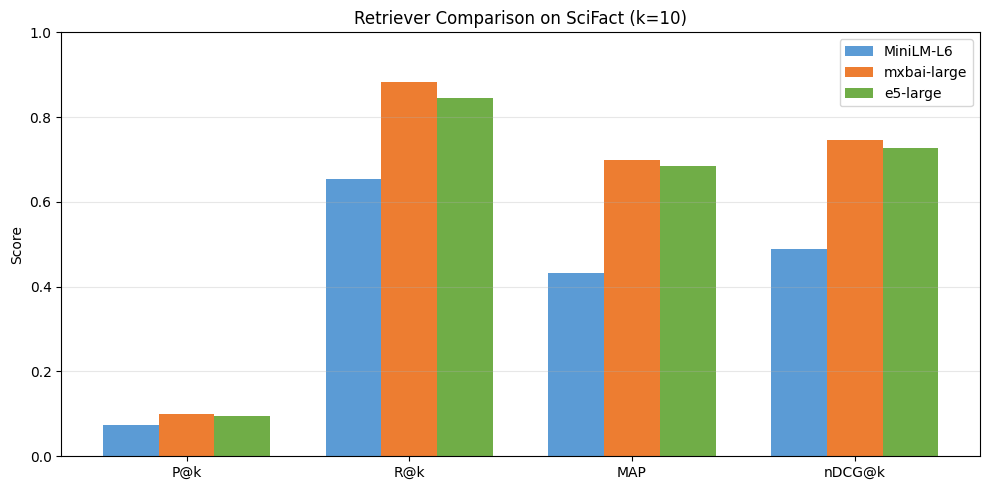

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

comparison = pd.DataFrame(results).T
print(comparison.to_string(float_format="{:.4f}".format))

# Grouped bar chart
x = np.arange(len(comparison.columns))
n_models = len(comparison)
width = 0.25
colors = ["#5B9BD5", "#ED7D31", "#70AD47"]

fig, ax = plt.subplots(figsize=(10, 5))
for i, (label, row) in enumerate(comparison.iterrows()):
    ax.bar(x + i * width, row.values, width, label=label, color=colors[i])

ax.set_ylabel("Score")
ax.set_title(f"Retriever Comparison on SciFact (k={K})")
ax.set_xticks(x + width)
ax.set_xticklabels(comparison.columns)
ax.legend()
ax.set_ylim(0, 1)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### What just happened

We loaded a benchmark dataset, encoded the corpus with three different models,
retrieved documents for every query, and scored the results with formal IR metrics
— all with our own code.

This is exactly what the [MTEB Leaderboard](https://huggingface.co/spaces/mteb/leaderboard)
does under the hood, except MTEB runs across **dozens** of datasets and task types
(not just retrieval — also classification, clustering, reranking, etc.).

When you see an nDCG@10 score on the leaderboard, now you know what it means
and how it was computed.

### How to read the MTEB Leaderboard

1. **Filter by task type** — click "Retrieval". The overall score mixes tasks you may not care about.
2. **Check the model size** — a 7B-parameter model scores higher but is 100x slower to embed.
3. **Check the dimensions** — 1024-dim embeddings take 2.5x more storage than 384-dim.
4. **Check the max sequence length** — if your chunks are 512 tokens and the model caps at 128, it will truncate.

---

## 4. RAGAS: Evaluating the Full RAG Pipeline

Sections 1–3 evaluated the **retriever in isolation**. But the user doesn't see
retrieved documents — they see the generated answer.

[RAGAS](https://docs.ragas.io/) gives you out-of-the-box metrics for the full pipeline:

| Metric | What it checks | Why it matters |
|---|---|---|
| **Context Precision** | Were the retrieved docs actually relevant? | Junk context = confused model |
| **Faithfulness** | Is the answer grounded in the retrieved context? | Catches hallucinations |
| **Answer Relevancy** | Does the answer address the question? | Catches off-topic responses |

RAGAS uses an LLM to score each of these automatically — no manual labeling needed.
We use **Gemini** as both the RAG generator and the RAGAS evaluator (free tier).

### The workflow

```
Question → Retriever → Documents → Gemini → Answer
                                                  ↓
                   RAGAS scores each (question, context, answer) triple
```

### Why RAGAS and not manual evaluation?

For retrieval, we could compute metrics by hand because we had ground-truth labels.
For **generation quality** there is no ground truth — you'd need a human to read every
answer and judge it. RAGAS automates this with LLM-as-judge, which scales to hundreds
of queries.

In [ ]:
from langchain_google_genai import ChatGoogleGenerativeAI, GoogleGenerativeAIEmbeddings
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

llm = ChatGoogleGenerativeAI(model="gemini-3.1-flash-lite-preview", temperature=0)

rag_prompt = ChatPromptTemplate.from_template(
    """Answer the question using ONLY the provided context. Be concise.

Context:
{context}

Question: {question}"""
)

# Use the best retriever from Section 3
BEST_MODEL = "mxbai-large"  # change this based on your results above


def rag_answer(question, k=5):
    """Retrieve + generate: returns the answer and the retrieved contexts."""
    top_ids = retrieve(question, BEST_MODEL, k=k)
    contexts = [corpus_lookup[cid] for cid in top_ids]
    context_str = "\n\n".join(contexts)
    chain = rag_prompt | llm | StrOutputParser()
    answer = chain.invoke({"context": context_str, "question": question})
    # Handle Gemini content block format
    if isinstance(answer, list):
        answer = "".join(
            b.get("text", "") for b in answer
            if isinstance(b, dict) and b.get("type") == "text"
        )
    return answer, contexts


# Quick sanity check
sample_q = list(eval_queries.values())[0]
ans, ctxs = rag_answer(sample_q)
print(f"Q: {sample_q[:120]}...\n\nA: {ans}")

Q: 0-dimensional biomaterials show inductive properties....

A: The provided context does not mention 0-dimensional biomaterials or their inductive properties.


In [ ]:
from ragas import evaluate
from ragas.metrics import faithfulness, answer_relevancy, context_precision
from ragas.dataset_schema import SingleTurnSample, EvaluationDataset
from ragas.llms import LangchainLLMWrapper
from ragas.embeddings import LangchainEmbeddingsWrapper

# Step 1: Generate RAG answers for a sample of queries
sample_queries = list(eval_queries.items())[:5]

ragas_samples = []
print(f"Generating RAG answers for {len(sample_queries)} queries...")
for qid, qtext in sample_queries:
    answer, contexts = rag_answer(qtext, k=5)
    ragas_samples.append(
        SingleTurnSample(
            user_input=qtext,
            response=answer,
            retrieved_contexts=contexts,
            reference=qtext,
        )
    )
    print(".", end="", flush=True)

print(f"\n{len(ragas_samples)} samples ready for evaluation.")

/tmp/ipykernel_5391/1447962456.py:2: DeprecationWarning: Importing faithfulness from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import faithfulness
  from ragas.metrics import faithfulness, answer_relevancy, context_precision
/tmp/ipykernel_5391/1447962456.py:2: DeprecationWarning: Importing answer_relevancy from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import answer_relevancy
  from ragas.metrics import faithfulness, answer_relevancy, context_precision
/tmp/ipykernel_5391/1447962456.py:2: DeprecationWarning: Importing context_precision from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import context_precision
  from ragas.metrics import faithfulness, answer_relevancy, context_pr

Generating RAG answers for 5 queries...
.....
5 samples ready for evaluation.


In [ ]:
# Step 2: Run RAGAS with Gemini as the judge
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning, module="ragas")
eval_llm = LangchainLLMWrapper(
    ChatGoogleGenerativeAI(model="gemini-3.1-flash-lite-preview", temperature=0)
)
eval_emb = LangchainEmbeddingsWrapper(
    GoogleGenerativeAIEmbeddings(model="models/gemini-embedding-2-preview")
)

dataset = EvaluationDataset(samples=ragas_samples)

ragas_results = evaluate(
    dataset=dataset,
    metrics=[faithfulness, answer_relevancy, context_precision],
    llm=eval_llm,
    embeddings=eval_emb,
)

print("\nRAGAS Aggregate Scores:")
print(ragas_results)

/tmp/ipykernel_5391/1223884208.py:2: DeprecationWarning: LangchainLLMWrapper is deprecated and will be removed in a future version. Use llm_factory instead: from openai import OpenAI; from ragas.llms import llm_factory; llm = llm_factory('gpt-4o-mini', client=OpenAI(api_key='...'))
  eval_llm = LangchainLLMWrapper(
/tmp/ipykernel_5391/1223884208.py:5: DeprecationWarning: LangchainEmbeddingsWrapper is deprecated and will be removed in a future version. Use the modern embedding providers instead: embedding_factory('openai', model='text-embedding-3-small', client=openai_client) or from ragas.embeddings import OpenAIEmbeddings, GoogleEmbeddings, HuggingFaceEmbeddings
  eval_emb = LangchainEmbeddingsWrapper(


Evaluating:   0%|          | 0/15 [00:00<?, ?it/s]

ERROR:ragas.executor:Exception raised in Job[37]: TimeoutError()
ERROR:ragas.executor:Exception raised in Job[40]: TimeoutError()



RAGAS Aggregate Scores:
{'faithfulness': 1.0000, 'answer_relevancy': 0.3704, 'context_precision': 0.2000}


In [ ]:
# Step 3: Dig into per-sample results to find weak spots
ragas_df = ragas_results.to_pandas()

score_cols = [
    c for c in ["faithfulness", "answer_relevancy", "context_precision"]
    if c in ragas_df.columns
]

# Summary statistics
print("Per-query score distribution:")
print(ragas_df[score_cols].describe().round(3))

# Find the worst-performing samples by faithfulness
if "faithfulness" in ragas_df.columns:
    print("\n--- Lowest faithfulness (potential hallucinations) ---")
    worst = ragas_df.nsmallest(3, "faithfulness")
    for _, row in worst.iterrows():
        q = row.get("user_input", "")[:100]
        f_score = row.get("faithfulness", float("nan"))
        print(f"  [{f_score:.2f}] {q}...")

Per-query score distribution:
       faithfulness  answer_relevancy  context_precision
count           5.0             5.000              5.000
mean            1.0             0.370              0.200
std             0.0             0.507              0.447
min             1.0             0.000              0.000
25%             1.0             0.000              0.000
50%             1.0             0.000              0.000
75%             1.0             0.899              0.000
max             1.0             0.952              1.000

--- Lowest faithfulness (potential hallucinations) ---
  [1.00] 0-dimensional biomaterials show inductive properties....
  [1.00] 1,000 genomes project enables mapping of genetic sequence variation consisting of rare variants with...
  [1.00] 1/2000 in UK have abnormal PrP positivity....


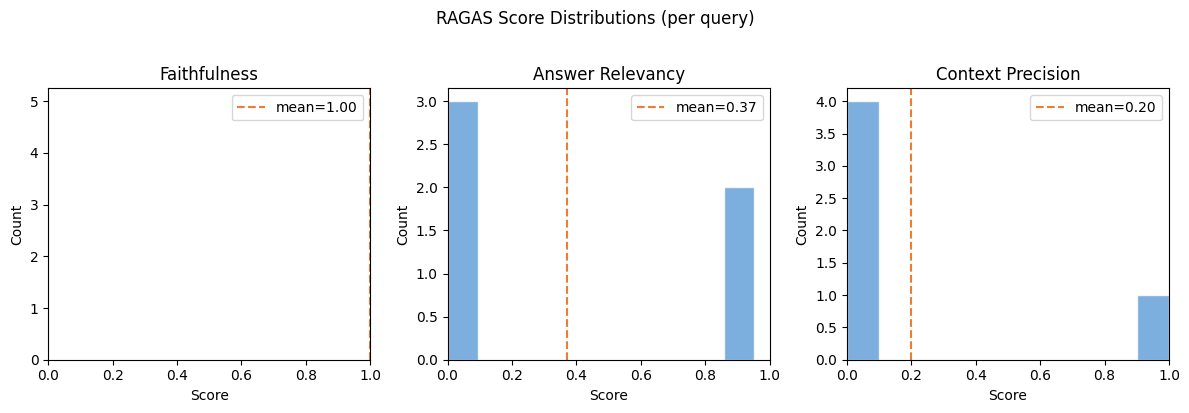

In [ ]:
# Step 4: Visualize score distributions
if score_cols:
    fig, axes = plt.subplots(1, len(score_cols), figsize=(4 * len(score_cols), 4))
    if len(score_cols) == 1:
        axes = [axes]

    for ax, col in zip(axes, score_cols):
        values = ragas_df[col].dropna()
        ax.hist(values, bins=10, color="#5B9BD5", edgecolor="white", alpha=0.8)
        ax.axvline(
            values.mean(), color="#ED7D31", linestyle="--",
            label=f"mean={values.mean():.2f}"
        )
        ax.set_title(col.replace("_", " ").title())
        ax.set_xlabel("Score")
        ax.set_ylabel("Count")
        ax.legend()
        ax.set_xlim(0, 1)

    plt.suptitle("RAGAS Score Distributions (per query)", y=1.02)
    plt.tight_layout()
    plt.show()

### Interpreting RAGAS Scores

The power of RAGAS is that it tells you **what to fix**:

| Symptom | Diagnosis | Fix |
|---|---|---|
| Low **Context Precision** | Retriever is pulling in junk | Try a better embedding model, reduce k, or improve chunking |
| Low **Faithfulness** | Model is hallucinating beyond the context | Strengthen the "only use the context" instruction, or use a more obedient model |
| Low **Answer Relevancy** but high Faithfulness | Answer is grounded but off-topic | Retrieval problem — the right docs aren't being found |

RAGAS separates **retrieval failures** from **generation failures**. That's the whole point.

---

## 5. ELO Ranking: Tuning *k* with LLM-as-Judge

How many documents should you feed to the model? More context can help, but it
can also dilute the signal with irrelevant passages.

We use **ELO rating** (the chess ranking system) to compare RAG answers generated
with $k \in \{3, 5, 10\}$. For each query, Gemini judges which answer is better,
and the ELO scores update accordingly.

In [ ]:
from collections import defaultdict

# ---- ELO setup ----
elo_scores = defaultdict(lambda: 1500)
ELO_K = 32


def expected_score(r1, r2):
    return 1 / (1 + 10 ** ((r2 - r1) / 400))


def update_elo(a, b, result):
    """result: 1 = a wins, 0 = b wins, 0.5 = draw."""
    ra, rb = elo_scores[a], elo_scores[b]
    ea = expected_score(ra, rb)
    elo_scores[a] += ELO_K * (result - ea)
    elo_scores[b] += ELO_K * ((1 - result) - (1 - ea))


# ---- Judge ----
judge_prompt = ChatPromptTemplate.from_template(
    """Compare two answers to the same scientific question.
Consider: Is it grounded in evidence? Is it complete? Is it clear?
Reply with ONLY "A" or "B" (the better answer) or "TIE".

Question: {question}

Answer A:
{answer_a}

Answer B:
{answer_b}

Winner:"""
)
judge_chain = judge_prompt | llm | StrOutputParser()

# ---- Tournament ----
ks = [3, 5, 10]
tournament_queries = list(eval_queries.items())[:10]

print(f"Running ELO tournament: {len(tournament_queries)} queries, k={ks}\n")
for qid, qtext in tournament_queries:
    answers = {}
    for k in ks:
        ans, _ = rag_answer(qtext, k=k)
        answers[f"k={k}"] = ans

    for i in range(len(ks)):
        for j in range(i + 1, len(ks)):
            a_key, b_key = f"k={ks[i]}", f"k={ks[j]}"
            try:
                verdict = judge_chain.invoke({
                    "question": qtext,
                    "answer_a": answers[a_key],
                    "answer_b": answers[b_key],
                })
                if isinstance(verdict, list):
                    verdict = "".join(
                        b.get("text", "") for b in verdict
                        if isinstance(b, dict) and b.get("type") == "text"
                    )
                verdict = verdict.strip().upper()
                if "A" in verdict and "B" not in verdict:
                    update_elo(a_key, b_key, 1)
                elif "B" in verdict and "A" not in verdict:
                    update_elo(a_key, b_key, 0)
                else:
                    update_elo(a_key, b_key, 0.5)
            except Exception as e:
                print(f"  Judge error: {e}")
                update_elo(a_key, b_key, 0.5)

print("\nFinal ELO Scores:")
for variant, score in sorted(elo_scores.items(), key=lambda x: -x[1]):
    print(f"  {variant}: {score:.0f}")

Running ELO tournament: 10 queries, k=[3, 5, 10]


Final ELO Scores:
  k=10: 1556
  k=5: 1501
  k=3: 1444


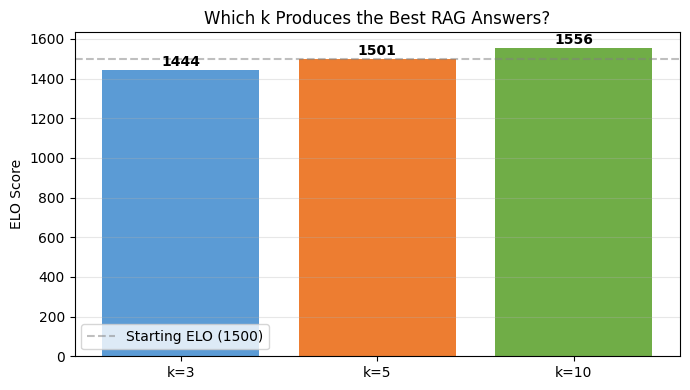

In [ ]:
# Visualize
elo_data = sorted(elo_scores.items(), key=lambda x: int(x[0].split("=")[1]))
elo_labels, elo_vals = zip(*elo_data)

colors = ["#5B9BD5", "#ED7D31", "#70AD47"]
plt.figure(figsize=(7, 4))
bars = plt.bar(elo_labels, elo_vals, color=colors[:len(elo_labels)])
plt.axhline(y=1500, color="gray", linestyle="--", alpha=0.5, label="Starting ELO (1500)")

for bar, val in zip(bars, elo_vals):
    plt.text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
        f"{val:.0f}", ha="center", va="bottom", fontweight="bold"
    )

plt.ylabel("ELO Score")
plt.title("Which k Produces the Best RAG Answers?")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

---

## Key Takeaways

1. **Always benchmark your retriever** before optimizing the prompt or the model.
   Precision@k and nDCG@k on a labeled dataset tell you if retrieval is the bottleneck.

2. **Prefixes are not optional.** Asymmetric and instruction-tuned models were trained
   with specific prefixes. Skipping them silently degrades performance. Always check the model card.

3. **Bigger models aren't always worth it.** The gap between a 22M and a 335M parameter
   model depends on your domain. Measure it on your data, don't assume.

4. **RAGAS separates retrieval failures from generation failures.** Low context precision =
   retrieval problem. Low faithfulness = generation problem. Fix the right thing.

5. **ELO with LLM-as-judge** is a practical way to compare configurations when you don't
   have ground-truth labels for generation quality.

---

## References

- [MTEB Leaderboard](https://huggingface.co/spaces/mteb/leaderboard)
- [BEIR: Benchmarking IR](https://github.com/beir-cellar/beir)
- [SciFact Dataset](https://huggingface.co/datasets/mteb/scifact)
- [RAGAS Documentation](https://docs.ragas.io/)
- [mxbai-embed-large-v1 — Model Card](https://huggingface.co/mixedbread-ai/mxbai-embed-large-v1)
- [e5-large-v2 — Model Card](https://huggingface.co/intfloat/e5-large-v2)
- [paraphrase-MiniLM-L6-v2 — Model Card](https://huggingface.co/sentence-transformers/paraphrase-MiniLM-L6-v2)